<a href="https://colab.research.google.com/github/rroy731993-web/assignment-01-bitsom_ba_2511993/blob/main/part7-vector-db%20/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


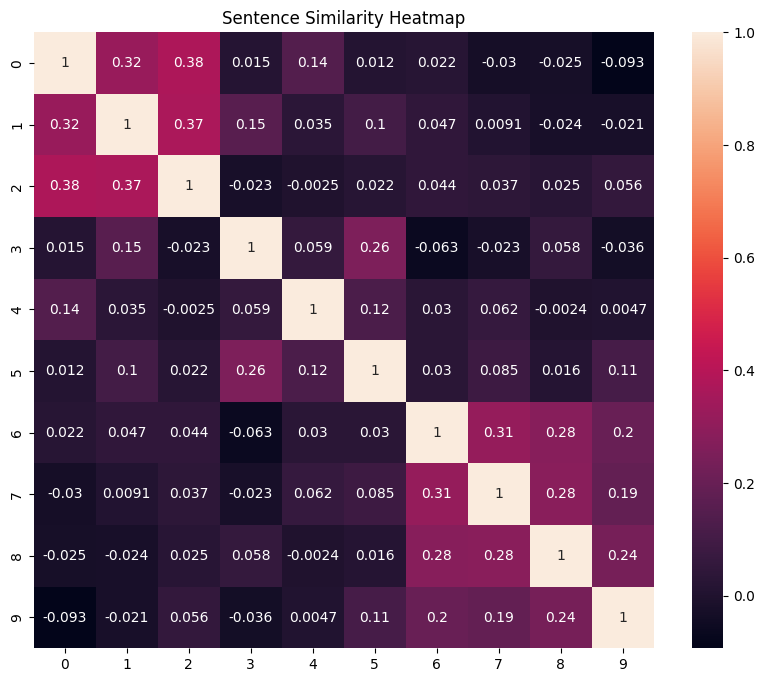

Sentence: The fast bowler delivered an excellent yorker
Similarity Score: 0.51709217

Sentence: The captain decided to bat first after winning the toss
Similarity Score: 0.4735883



In [5]:
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

sentences = [
    # Cricket
    "The captain decided to bat first after winning the toss",
    "The fast bowler delivered an excellent yorker",
    "The fielders saved many runs during the match",

    # Cooking
    "She prepared a delicious vegetable soup for dinner",
    "Baking bread requires patience and the right temperature",
    "Spices enhance the flavor of any dish",

    # Cybersecurity
    "Two-factor authentication improves account security",
    "Phishing emails are used to trick users into sharing information",
    "Encryption protects data from unauthorized access",
    "Regular software updates help prevent security vulnerabilities"
]

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True)
plt.title("Sentence Similarity Heatmap")
plt.show()

query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

import numpy as np

top_indices = np.argsort(similarities)[-2:][::-1]

for idx in top_indices:
    print("Sentence:", sentences[idx])
    print("Similarity Score:", similarities[idx])
    print()